<h3 style="color: #00ff00;">Questões - Statsmodels</h3>

In [18]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

<h4>Exercício 1: Análise de Distribuição de Receita Mensal</h4>

- Contexto: Uma loja online deseja entender a variabilidade das receitas mensais para ajustar seu fluxo de caixa.
- Tarefa: Carregue os dados simulados de receita mensal e apresente um relatório com média, mediana, desvio-padrão, assimetria e curtose. Visualize a distribuição e interprete se ela é simétrica, à direita ou à esquerda.
- Resultado esperado: Descreva a tendência central e a dispersão, comente se a média representa bem o conjunto.

In [5]:
np.random.seed(10)                            # Seed para garantir reprodutibilidade
receita = np.random.normal(50000, 8000, 100)  # Cria dados de receita
df = pd.DataFrame({"Receita": receita})       # Cria um dataframe
df.head()                                     # Visualização parcial da tabela

,Receita
0,60652.692033
1,55722.231795
2,37636.797663
3,49932.929201
4,54970.687791


In [10]:
df.describe()                                 # Resumo estatístico da coluna Receita

,Receita
count,100.000000
mean,50635.333303
std,7775.289947
min,32946.303132
25%,46128.766733
50%,50754.947314
75%,55377.709347
max,69741.208451


In [7]:
df.describe().T                                 # Visualização Transposta

,count,mean,std,min,25%,50%,75%,max
Receita,100.0,50635.333303,7775.289947,32946.303132,46128.766733,50754.947314,55377.709347,69741.208451


- Média: é o valor obtido somando todos os dados e dividindo pela quantidade de elementos, representando o "centro" dos valores;
- Mediana: é o valor central quando os dados são colocados em ordem, separando a metade menor da metade maior;
- Desvio-padrão: mede o quanto os valores se afastam da média, quanto maior, mais dispersos estão os dados;
- Assimetria: indica se os dados estão distribuidos de forma equilibrada em torno da média; se há cauda mais longa à direita ou à esquerda;
- Curtose: mostra o quão "achatada" ou "pontuda" é a distribuição em comparação com a normal; valores altos indicam picos acentuados e caudas longas.

print("Assimetria: ", df["Receita"].skew()) # Solução
print("Curtose: ", df["Receita"].kurtosis())
display(Markdown(f"""
- A assimetria de {df["Receita"].skew():.3f} está muito próxima de zero, indicando que a distribuição é praticamente simétrica, ou seja,
os valores se distribuem de forma equilibrada em torno da média, sem cauda mais longa à direita e à esquerda.
- A curtose de {df["Receita"].kurtosis():.3f} também está próxima de zero, sugerindo que a distribuição é mesocúrtica, semelhante À distribuição normal,
nem muito pontuda (leptocúrtica), nem muito achatada (platicúrtica).
"""))

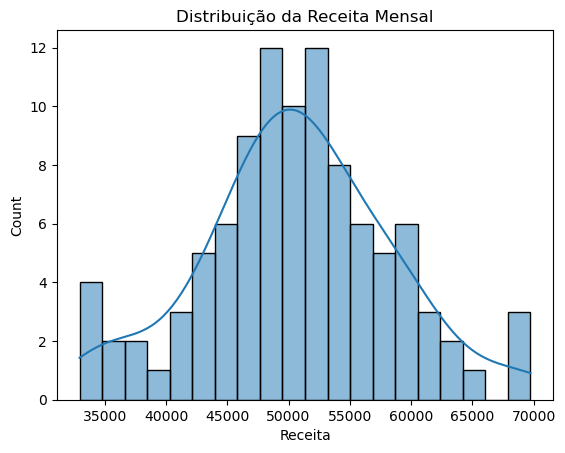

In [22]:
sns.histplot(df["Receita"], bins = 20, kde = True) # Solução
plt.title("Distribuição da Receita Mensal")
plt.show()

<h4>Exercício 2: Desempenho por Segmento de Cliente</h4>

- Contexto: uma empresa quer comparar o valor médio gasto por clientes novos e antigos;
- Tarefa: para os dois grupos (clientes novos e antigos), calcule média, mediana e desvio-padrão, e compare visualmente com boxplot. Discuta se há sobreposição entre os grupos e qual apresenta maior variabilidade;
- Resultado esperado: indique a diferença de média e dispersão, e o que isso sugere sobre o perfil de gasto.

In [28]:
np.random.seed(5)         # Seed
clientes = pd.DataFrame({ # DataFrame
    "Grupo": ["Novo"] * 80 + ["Antigo"] * 80,
    "Gasto": np.concatenate([np.random.normal(100, 40, 80), np.random.normal(230, 35, 80)])
})
clientes.sample(10)       # Visualiza dados

,Grupo,Gasto
122,Antigo,216.853270
119,Antigo,229.406914
143,Antigo,207.787163
40,Novo,87.765879
4,Novo,104.384394
27,Novo,85.467565
150,Antigo,279.075832
106,Antigo,200.373598
82,Antigo,256.100443
50,Novo,156.535921


In [27]:
# Solução
resumo = clientes.groupby("Grupo")["Gasto"].describe()
resumo

,count,mean,std,min,25%,50%,75%,max
Grupo,,,,,,,,
Antigo,80.0,232.921448,38.388523,148.253236,205.127578,231.443713,257.624944,318.228267
Novo,80.0,102.692648,38.652415,-14.387519,82.151568,97.481971,126.822797,197.230847


- Os clientes antigos gastam, em média, mais (232,9) do que os novos (102,7), indicando um perfil de consumo mais elevado. O desvio-padrão é parecido entre os grupos (=38), mostrando variabilidade semelhante nos gastos.
- No boxplot, deve haver pouca sobreposição, já que as faixas interquartis são diferentes. Isso sugere que, em geral, clientes antigos mantêm gastos consistentemente maiores, enquantos os novos ainda estão em fase de consumo menor, embora om dispersão parecida. 

In [ ]:
# Solução
sns.boxplot(data=clientes, x = "Grupo", y = "Gasto")
plt.title("Comparação do Gasto por Segmento")
plt.show()

Um boxplot típico mostra a distribuição de dados de forma visual e resumida. Ele é composto por uma caixa (box) que representa o intrvalo ente o primmeiro quartil (Q1) e o terceiro quartil (Q3), ou seja, onde está concentrada metade dos valores. 
Dentro da caixa há uma linha central que indica a mediana, o valor central dos dados. Os "bigodes" (whiskers) se estendem a partir da caixa ate os valores minimos e máximos dentro de um limite considerado normal. Pontos que ficam fora desses limites são mostrados como outliers, representando valores atípicos. Assim, o boxplot permite identificar rapidamente a tendência central, a dispersão e possíveis assimetrias ou outliers em um conjunto de dados. 

<h4>Exercício 3: Correlação entre Horas de Estudo e Nota</h4>

- Contexto: um professor quer saber se o tempo de estudo está associado ao desempenho dos alunos;
- Tarefa: calcule a correlação de Pearson e gere o gráfico de dispersão com linha de regressão. Interprete o grau e a direçã da relação;
- Resultado esperado: descreva se há correlação positiva, negativa ou nula, e o que significa em termos práticos.

In [33]:
np.random.seed(2)                                 # Seed
hrs = np.random.uniform(1, 10, 50)                # Define as horas
notas = 5*hrs + np.random.normal(0, 5, 50)      # Define as notas
df = pd.DataFrame({"Horas": hrs, "Notas": notas}) # Cria df
df.head()

,Horas,Notas
0,4.923954,20.474094
1,1.233336,6.605232
2,5.946962,34.736641
3,4.917902,22.684045
4,4.783310,22.038204


In [34]:
print(df.corr()) # Solução
display(Markdown(f"""
- O valor {df.corr()} representa uma correlação forte e positiva entre horas de estudo e nota. Isso significa que, quanto mais horas o aluno estuda, mair tende a ser sua nota. Como o valor está próximo de 1, a relação é uase linear e direta.
- Lembre-se: Correlação não implica causalidade!
"""))

          Horas     Notas
Horas  1.000000  0.914853
Notas  0.914853  1.000000



- O valor           Horas     Notas
Horas  1.000000  0.914853
Notas  0.914853  1.000000 representa uma correlação forte e positiva entre horas de estudo e nota. Isso significa que, quanto mais horas o aluno estuda, mair tende a ser sua nota. Como o valor está próximo de 1, a relação é uase linear e direta.
- Lembre-se: Correlação não implica causalidade!


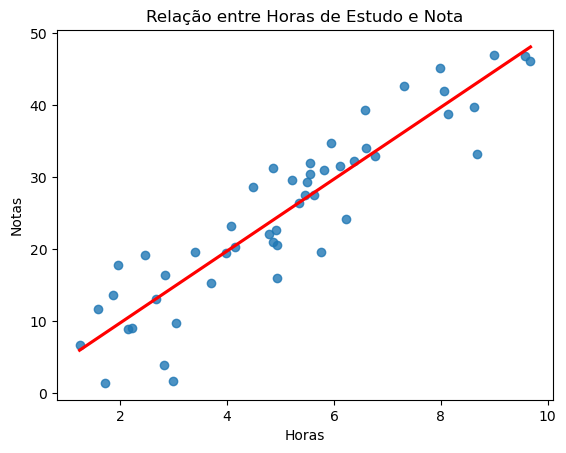

In [36]:
# Solução gráfica
sns.regplot(data=df, x="Horas", y="Notas", ci=None, line_kws={"color": "red"})
plt.title("Relação entre Horas de Estudo e Nota")
plt.show()

<h4>Exercício 4: Variação Semanal de Vendas</h4>

- Contexto: o gestor deseja entender como as vendas variam ao longo da semana;
- Tarefa: simule dados de vendas diárias, calcule média e desvio por dia da semana e gere um gráfico de barras. Interprete os dias de maior e menor performace;
- Resultado esperado: identifique os dias mais fortes e mais fracos, e comente sobre a estabilidade semanal das vendas.

In [37]:
np.random.seed(3)
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
vendas = pd.DataFrame({
    "Dia": np.random.choice(dias, 200),
    "Vendas": np.random.normal(1000, 150, 200)
})
vendas.head()

,Dia,Vendas
0,Qua,911.338189
1,Seg,922.537395
2,Ter,856.000573
3,Qui,1056.594285
4,Seg,913.793737


In [38]:
# Solução
resumo = vendas.groupby("Dia")["Vendas"].agg(["mean", "std"]).sort_values("mean", ascending=False)
resumo

,mean,std
Dia,,
Sex,1049.790137,152.085006
Dom,1034.716174,161.899699
Qui,1027.466786,196.069107
Sab,1021.630030,133.611346
Qua,1009.722472,134.496526
Seg,1008.344683,121.895506
Ter,990.271715,142.264723


- As maiores médias de vendas ocorrem na sexta (1049,8), indicaando picos próximos ao fim de semana. Já a terça-feira (990,3) tem o menor desempenho;
- O desvio-padrão é moderado, sugerindo variação regular entre os dias, mas um leve aumento de instabilidade nas quintas;
- Em resumo, as vendas se mantêm estáveis ao longo da semana, com melhor performace nos dias próximos ao fim de semana.

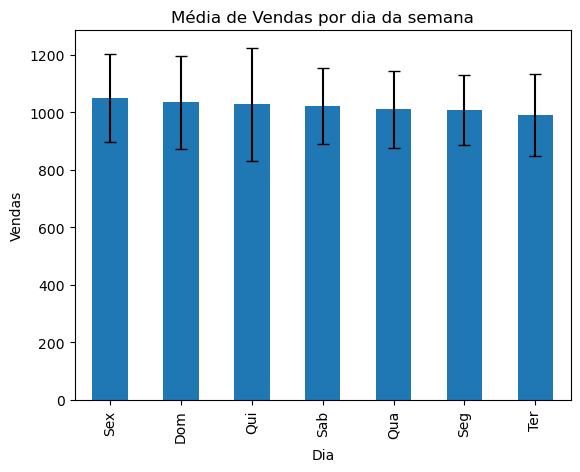

In [39]:
resumo["mean"].plot(kind="bar", yerr = resumo["std"], capsize=4)
plt.title("Média de Vendas por dia da semana")
plt.ylabel("Vendas")
plt.show()

<h4>Exercício 5: Estimativa da Média com Intervalos de Confiança (statsmodels)</h4>

- Contexto: um analista de RH quer estimar a altura média dos colaboradores com 95% de confiança;
- Tarefa: calcule a média e o intervalo de confiança usando o DescrStatsW do Statsmodels. Interprete o resultado como se fosse parte de um relatório técnico;
- Resultado esperado: apresente a altura média estimada e explique o significado do intervalo de confiança no contexto da amostra.

In [41]:
from statsmodels.stats.weightstats import DescrStatsW

np.random.seed(7)
alturas = np.random.normal(1.75, 0.80, 40)

In [42]:
# Solução 
desc = DescrStatsW(alturas)
print(f"Média estimada: {round(desc.mean, 3)}")
print(f"Intervalo de Confiança (95%): {desc.tconfint_mean()}")

Média estimada: 1.67
Intervalo de Confiança (95%): (np.float64(1.3931266770741475), np.float64(1.946491810206263))


- A média estimada é de 1.67, e o intervalo de confiança de 95% indica que há alta probabilidade de a média real da população estar entre 1.39 e 1.94. Isso mostra uma estimativa precisa, com variação pequena em torno da média.